# Import Packages

In [1]:
import arviz as az
import numpy as np
import pyjags
import xarray as xr
xr.set_options(display_style="html");

This notebook illustrates the modeling of the eight schools dataset which is a classical example in Bayesian hierarchical analysis. For each school, the given data are the estimated treatment effect and the standard error of the treatment effect of an experiment conducted in the late 1970s concerning SAT-V scores.

# Construct Data Dictionary

In [2]:
# eight_schools_data = {
#     "J": 8, 
#     "y": np.array([28.0, 8.0, -3.0, 7.0, -1.0, 1.0, 18.0, 12.0]),
#     "sigma": np.array([15.0, 10.0, 16.0, 11.0, 9.0, 11.0, 10.0, 18.0]),
# }

eight_schools_data = {
    "J": 8, 
    "y": np.array([28.39, 7.94, -2.75 , 6.82, -0.64, 0.63, 18.01, 12.16]),
    "sigma": np.array([14.9, 10.2, 16.3, 11.0, 9.4, 11.4, 10.4, 17.6]),
}

# JAGS Model Code

## Prior Model

In [3]:
eight_school_prior_model_code = ''' 
model {
    mu ~ dnorm(0.0, 1.0/25)
    tau ~ dt(0.0, 1.0/25, 1.0) T(0, )
    for (j in 1:J) {
        theta_tilde[j] ~ dnorm(0.0, 1.0)
    }
}
'''

## Posterior Model

In [4]:
eight_school_posterior_model_code = ''' 
model {
    mu ~ dnorm(0.0, 1.0/25)
    tau ~ dt(0.0, 1.0/25, 1.0) T(0, )
    for (j in 1:J) {
        theta_tilde[j] ~ dnorm(0.0, 1.0)
        y[j] ~ dnorm(mu + tau * theta_tilde[j], 1.0/(sigma[j]^2))
        log_like[j] = logdensity.norm(y[j], mu + tau * theta_tilde[j], 1.0/(sigma[j]^2))
    }
}
'''

## Define Parameters

In [5]:
parameters = ['mu', 'tau', 'theta_tilde']
variables = parameters + ['log_like']

# Construct JAGS Model

## Prior Model

In [6]:
jags_prior_model = pyjags.Model(
    code=eight_school_prior_model_code, 
    data={"J": 8}, 
    chains=4, 
    threads=4,
    chains_per_thread=1
)

## Posterior Model

In [7]:
jags_posterior_model = pyjags.Model(
    code=eight_school_posterior_model_code, 
    data=eight_schools_data, 
    chains=4, 
    threads=4,
    chains_per_thread=1
)

adapting: iterations 4000 of 4000, elapsed 0:00:00, remaining 0:00:00


# Draw Samples

Draw burn-in sample of 1000 iterations

In [8]:
jags_prior_model.sample(1000, vars=[])
jags_posterior_model.sample(1000, vars=[])

sampling: iterations 4000 of 4000, elapsed 0:00:00, remaining 0:00:00
sampling: iterations 4000 of 4000, elapsed 0:00:00, remaining 0:00:00


{}

Draw actual sample of 5000 iterations

In [9]:
jags_prior_samples = jags_prior_model.sample(5000, vars=parameters)
jags_posterior_samples = jags_posterior_model.sample(5000, vars=variables)

sampling: iterations 20000 of 20000, elapsed 0:00:00, remaining 0:00:00
sampling: iterations 20000 of 20000, elapsed 0:00:00, remaining 0:00:00


Convert dictionary of samples to Arviz object

In [10]:
pyjags_data = pyjags.from_pyjags(
    posterior=jags_posterior_samples, 
    prior=jags_prior_samples, 
    log_likelihood={'y': 'log_like'}, 
    save_warmup=True, 
    warmup_iterations=1000
)
pyjags_data

<xarray.DataTree>
Group: /
├── Group: /warmup_posterior
│       Dimensions:            (chain: 4, draw: 1000, theta_tilde_dim_0: 8)
│       Coordinates:
│         * chain              (chain) int64 32B 0 1 2 3
│         * draw               (draw) int64 8kB 0 1 2 3 4 5 ... 994 995 996 997 998 999
│         * theta_tilde_dim_0  (theta_tilde_dim_0) int64 64B 0 1 2 3 4 5 6 7
│       Data variables:
│           theta_tilde        (chain, draw, theta_tilde_dim_0) float64 256kB -0.3091...
│           mu                 (chain, draw) float64 32kB 10.83 3.122 ... 7.944 3.229
│           tau                (chain, draw) float64 32kB 4.038 4.404 ... 0.5466 0.829
│       Attributes:
│           created_at:                 2026-03-13T18:31:16.230974+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.0.0
│           creation_library_language:  Python
├── Group: /warmup_log_likelihood
│       Dimensions:  (chain: 4, draw: 1000, y_dim_0: 8)
│       Coordinates:
│         * chain    (chain) int64 32B 0 1 2 3
│         * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
│         * y_dim_0  (y_dim_0) int64 64B 0 1 2 3 4 5 6 7
│       Data variables:
│           y        (chain, draw, y_dim_0) float64 256kB -4.417 -3.423 ... -4.24 -3.879
│       Attributes:
│           created_at:                 2026-03-13T18:31:16.232370+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.0.0
│           creation_library_language:  Python
├── Group: /posterior
│       Dimensions:            (chain: 4, draw: 4000, theta_tilde_dim_0: 8)
│       Coordinates:
│         * chain              (chain) int64 32B 0 1 2 3
│         * draw               (draw) int64 32kB 0 1 2 3 4 ... 3995 3996 3997 3998 3999
│         * theta_tilde_dim_0  (theta_tilde_dim_0) int64 64B 0 1 2 3 4 5 6 7
│       Data variables:
│           theta_tilde        (chain, draw, theta_tilde_dim_0) float64 1MB -0.02201 ...
│           mu                 (chain, draw) float64 128kB 4.98 6.027 ... 4.458 3.707
│           tau                (chain, draw) float64 128kB 0.426 4.693 ... 2.885 0.371
│       Attributes:
│           created_at:                 2026-03-13T18:31:16.233286+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.0.0
│           creation_library_language:  Python
├── Group: /log_likelihood
│       Dimensions:  (chain: 4, draw: 4000, y_dim_0: 8)
│       Coordinates:
│         * chain    (chain) int64 32B 0 1 2 3
│         * draw     (draw) int64 32kB 0 1 2 3 4 5 6 ... 3994 3995 3996 3997 3998 3999
│         * y_dim_0  (y_dim_0) int64 64B 0 1 2 3 4 5 6 7
│       Data variables:
│           y        (chain, draw, y_dim_0) float64 1MB -4.856 -3.276 ... -4.172 -3.883
│       Attributes:
│           created_at:                 2026-03-13T18:31:16.234290+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.0.0
│           creation_library_language:  Python
└── Group: /prior
        Dimensions:            (chain: 4, draw: 5000, theta_tilde_dim_0: 8)
        Coordinates:
          * chain              (chain) int64 32B 0 1 2 3
          * draw               (draw) int64 40kB 0 1 2 3 4 ... 4995 4996 4997 4998 4999
          * theta_tilde_dim_0  (theta_tilde_dim_0) int64 64B 0 1 2 3 4 5 6 7
        Data variables:
            theta_tilde        (chain, draw, theta_tilde_dim_0) float64 1MB 0.8069 .....
            tau                (chain, draw) float64 160kB 29.74 2.963 ... 3.957 5.835
            mu                 (chain, draw) float64 160kB 1.828 6.91 ... 1.846 -6.391
        Attributes:
            created_at:                 2026-03-13T18:31:16.235183+00:00
            creation_library:           ArviZ
            creation_library_version:   1.0.0
            creation_library_language:  Python

# Compute Diagnostics

## Compute Gelman-Rubin Statistic

In [11]:
az.rhat(pyjags_data)

<xarray.DataTree 'posterior'>
Group: /posterior
    Dimensions:            (theta_tilde_dim_0: 8)
    Coordinates:
      * theta_tilde_dim_0  (theta_tilde_dim_0) int64 64B 0 1 2 3 4 5 6 7
    Data variables:
        theta_tilde        (theta_tilde_dim_0) float64 64B 1.0 0.9999 ... 1.0 0.9999
        mu                 float64 8B 1.0
        tau                float64 8B 1.001

A Gelman-Rubin substantially different from unity indicates non-convergence of the Markov chains.

## Generate Autocorrelation Plot

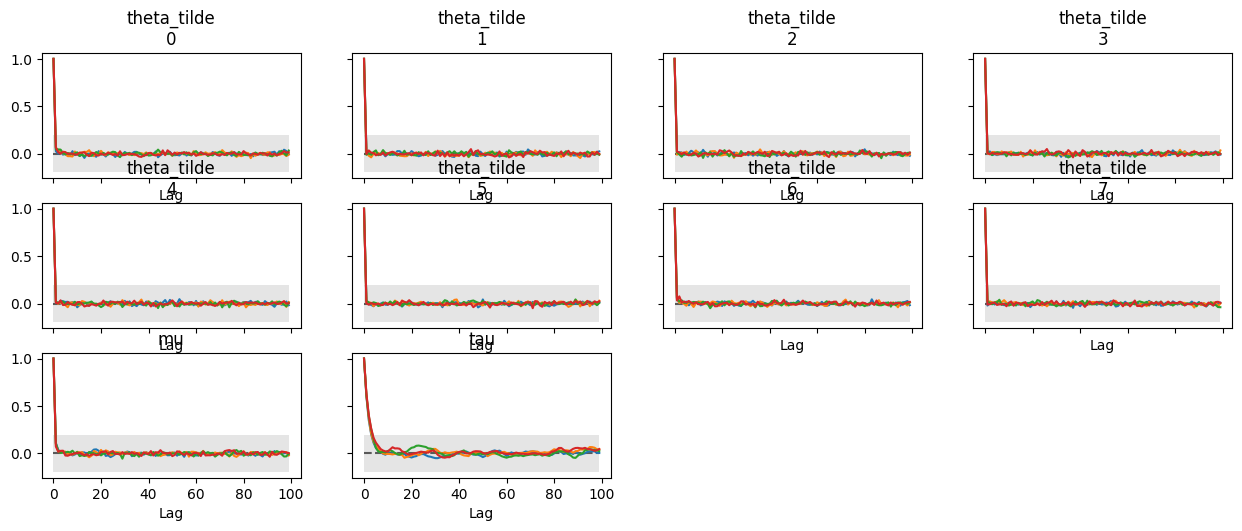

In [12]:
az.plot_autocorr(pyjags_data);

## Compute effective sample size

In [13]:
az.ess(pyjags_data)

<xarray.DataTree 'posterior'>
Group: /posterior
    Dimensions:            (theta_tilde_dim_0: 8)
    Coordinates:
      * theta_tilde_dim_0  (theta_tilde_dim_0) int64 64B 0 1 2 3 4 5 6 7
    Data variables:
        theta_tilde        (theta_tilde_dim_0) float64 64B 1.32e+04 ... 1.482e+04
        mu                 float64 8B 1.226e+04
        tau                float64 8B 4.697e+03

## Generate Trace Plot

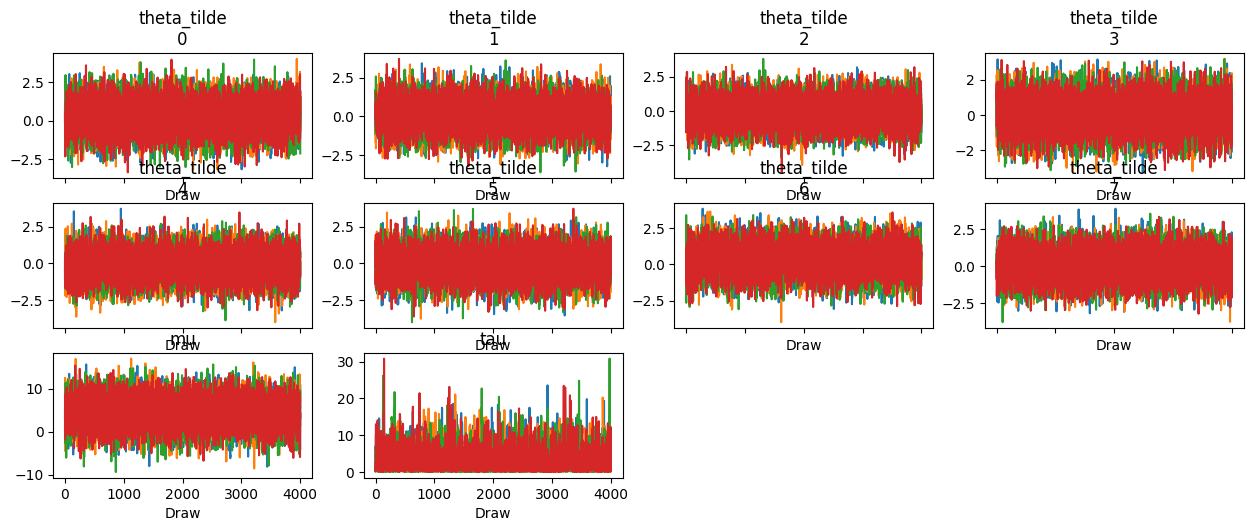

In [14]:
az.plot_trace(pyjags_data);

## Compute Summary Statistics

In [15]:
az.summary(pyjags_data)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
theta_tilde[0],0.32,0.99,-1.3,1.9,13200,14563,1.00,0.0086,0.0061
theta_tilde[1],0.09,0.94,-1.4,1.6,15562,15427,1.00,0.0075,0.0054
theta_tilde[2],-0.09,0.97,-1.6,1.5,15477,14732,1.00,0.0078,0.0055
theta_tilde[3],0.06,0.94,-1.4,1.6,15157,15407,1.00,0.0076,0.0054
theta_tilde[4],-0.14,0.93,-1.6,1.4,14695,14579,1.00,0.0077,0.0055
theta_tilde[5],-0.08,0.94,-1.6,1.4,15418,15408,1.00,0.0076,0.0055
theta_tilde[6],0.33,0.96,-1.2,1.8,12425,13932,1.00,0.0086,0.0062
theta_tilde[7],0.07,0.98,-1.5,1.6,14824,15618,1.00,0.008,0.0057
mu,4.43,3.34,-0.97,9.7,12258,13209,1.00,0.03,0.022
tau,3.6,3.2,0.29,9.5,4697,5148,1.00,0.051,0.066


## Generate Posterior Plot

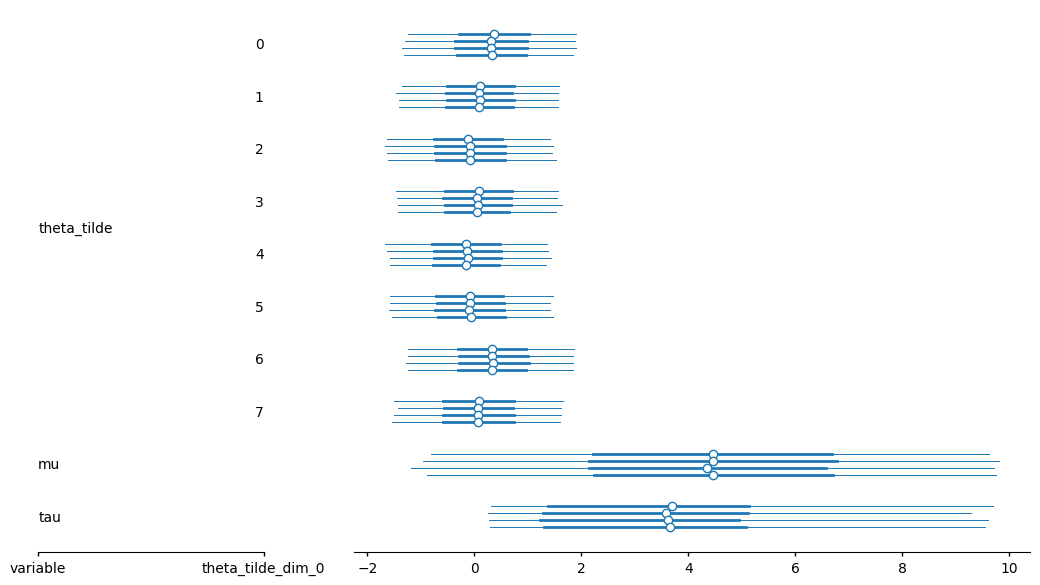

In [16]:
az.plot_forest(pyjags_data);

Compute WAIC

In [17]:
az.loo(pyjags_data);